### Root finding algorithms comparison

Solve:

$$
    \sqrt{1 - x} = x
$$

We'll use:

- Picard method
- Steffensen method
- Newton method

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fast')

In [2]:
def f(x): return np.sqrt(1.0 - x) # lhs of the equation f(x)
def fp(x): return - 1.0 / (2.0 * f(x)) # derivative of f(x)

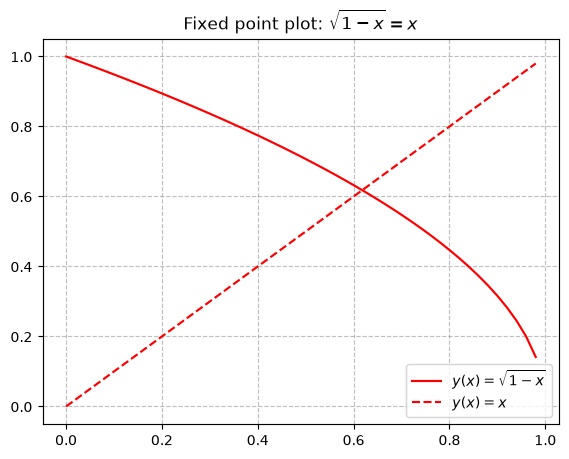

In [3]:
# Plotting the equation
x = np.linspace(0.0, 1.0, 50, endpoint = False)
plt.title(r'Fixed point plot: $\sqrt{1 - x} = x$')
plt.plot(x, f(x), color = 'red', linestyle = 'solid', label = r'$y(x) = \sqrt{1 - x}$')
plt.plot(x, x, color = 'red', linestyle = 'dashed', label = r'$y(x) = x$')
plt.legend(loc = 'best')
plt.grid(True, alpha = 0.5, linestyle = 'dashed', color = 'gray')
plt.show()

Initial guess: $x = 0.6$

To solve a fixed-point problem $f(x) = x$, we must ensure that:

$$
    L \triangleq \sup_{x \text{ close to } x_0} \left| f'(x) \right| < 1
$$

Let's find $L$ by plotting $|f'(x)|$

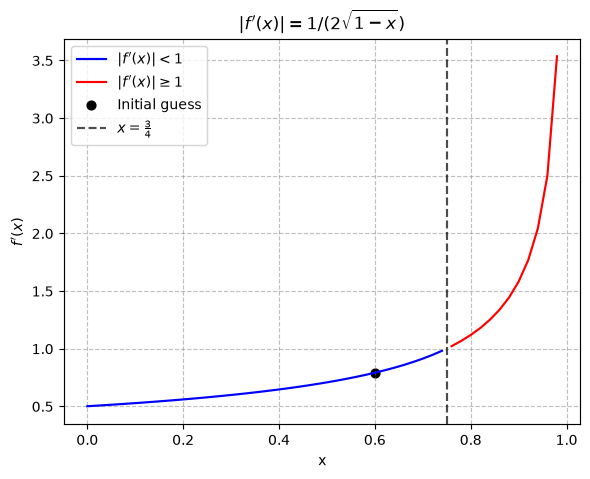

In [4]:
# Plotting |f'(x)| near x0
yp = np.abs(fp(x))
mask = (yp >= 1)

plt.plot(x[~mask], np.abs(yp[~mask]), color = 'blue', label = r'$|f^\prime(x)| < 1$') # Blue: |f'(x)| < 1
plt.plot(x[mask], np.abs(yp[mask]), color = 'red', label = r'$|f^\prime(x)| \geq 1$') # Red: |f'(x)| >= 1
plt.scatter(0.6, np.abs(fp(0.6)), color = 'black', label = 'Initial guess')
plt.axvline(0.75, color = 'black', linestyle = '--', alpha = 0.7, label = r'$x = \frac{3}{4}$') # Threshold
plt.xlabel('x')
plt.ylabel(r"$f'(x)$")
plt.title(r"$|f'(x)| = 1 / (2 \sqrt{1 - x})$")
plt.grid(True, alpha = 0.5, linestyle = 'dashed', color = 'gray')
plt.legend(loc = 'best')
plt.show()

As we can easily see, in the range $[0, \frac{3}{4}]$ the absolute value of the derivative of $f(x)$ with respect to $x$ is less than 1. We can solve the fixed point problem. We can compute $L$ as $L = |f'(0.6)|$

In [5]:
# Setup
x0 = 0.6
L = np.abs(fp(x0))
L

np.float64(0.7905694150420948)

In [6]:
def picard(f, x0, L, atol = 1e-06, rtol = 1e-03, N = 100): # Picard method implementation with error estimation using L

    x = x0
    for j in range(1, N + 1):
        
        fx = f(x)
        
        err = np.abs(fx - x) / (1.0 - L) # Error bound of x
        if err < (atol + rtol * np.abs(x)):
            print(f"Loop terminated after {j} iterations. Error under the threshold")
            return x, err

        x = fx # Update x

    # Maximum iterations reached: recompute residual for returned x
    print(f"Loop terminated after {j} iterations. Maximum number of iterations reached")
    
    fx = f(x)
    err = np.abs(fx - x) / (1.0 - L)

    return x, err

In [7]:
picard(f, x0, L) # Picard with defaults arguments

Loop terminated after 28 iterations. Error under the threshold


(np.float64(0.6180926412903538), np.float64(0.0005066369087770095))

In [8]:
picard(f, x0, L, atol = 0.0, rtol = 1e-06) # Picard with low tolerances [1]

Loop terminated after 60 iterations. Error under the threshold


(np.float64(0.6180340552681214), np.float64(5.745703502262756e-07))

In [9]:
picard(f, x0, L, atol = 0.0, rtol = 1e-09) # Picard with low tolerances [2]

Loop terminated after 93 iterations. Error under the threshold


(np.float64(0.6180339886888649), np.float64(5.271633572746559e-10))

In [10]:
def steffensen(f, x0, L, atol = 1e-06, rtol = 1e-03, N = 100): # Steffensen method implementation with error estimation using L

    x = x0
    for j in range(1, N + 1):
        
        fx = f(x)
        ffx = f(fx)

        denom = ffx - 2.0 * fx + x
        x_new = ffx if (denom == 0.0) else (x - (fx - x) ** 2 / denom) # Steffensen step if possible. If denom is zero fallback to 2 Picard steps

        err = np.abs(f(x_new) - x_new) / (1.0 - L) # Error bound for x_new

        if err < (atol + rtol * np.abs(x_new)):
            print(f"Loop terminated after {j} iterations. Error under the threshold")
            return x_new, err

        x = x_new

    # Maximum number of iterations reached: recompute residual at returned x
    print(f"Loop terminated after {j} iterations. Maximum number of iterations reached")
    err = np.abs(f(x) - x) / (1.0 - L)

    return x, err

In [11]:
steffensen(f, x0, L) # Steffensen with defaults arguments

Loop terminated after 2 iterations. Error under the threshold


(np.float64(0.6180339873864307), np.float64(1.1777314520389209e-08))

In [12]:
steffensen(f, x0, L, atol = 0.0, rtol = 1e-09) # Steffensen with low tolerances

Loop terminated after 3 iterations. Error under the threshold


(np.float64(0.6180339887498949), np.float64(5.30115037805155e-16))

In [13]:
def newton(f, x0, eps = 1e-12, atol = 1e-06, rtol = 1e-03, N = 100):
    
    x = x0
    for j in range(1, N + 1):
        
        x_new = (2.0 - x) / (2.0 * np.sqrt(1.0 - x) + 1.0) # Newton step for f(x) = sqrt(1 - x) - x
        fx = f(x_new)
        err = np.abs(x_new - x) # Error bound for x
        x = x_new  # Update before convergence checks

        if np.abs(fx) < eps:
            print(f"Loop ended after {j} iterations. f(x) is under the threshold")
            break
        elif err < (atol + rtol * np.abs(x)):
            print(f"Loop ended after {j} iterations. Error x is under the threshold")
            break
    else:
        print(f"Loop ended after {j} iterations. Maximum number of iterations reached")

    return x, err, fx

In [14]:
newton(lambda x: f(x) - x, x0) # Newton is a root finding method: g(x) = sqrt(1 - x) - x = 0

Loop ended after 2 iterations. Error x is under the threshold


(np.float64(0.6180339912185248),
 np.float64(9.182493862913699e-05),
 np.float64(-4.465793512764549e-09))

In [15]:
newton(lambda x: f(x) - x, x0, eps = 1e-16, atol = 0.0, rtol = 1e-12) # Newton low tolerances

Loop ended after 4 iterations. Error x is under the threshold


(np.float64(0.6180339887498949),
 np.float64(1.1102230246251565e-16),
 np.float64(-1.1102230246251565e-16))

In [16]:
(np.sqrt(5.0) - 1.0) / 2.0 # Real value

# Steffensen and Newton reach machine precision very fast

np.float64(0.6180339887498949)